# Hybrid Dataset Demo: EV Charger QR Recovery

This notebook demonstrates the data strategy for the Tap Electric interview project. It generates reproducible charger stickers with exact labels, simulates real scan failures, checks leakage-safe splits, and measures the deterministic QR baseline.

> The notebook does **not** claim production model accuracy. Synthetic data bootstraps development; public degraded-QR data and held-out physical captures provide broader evaluation; verified Tap scans are the eventual domain dataset.

## 1. Generate a reproducible demonstration dataset

Every generated example has an exact `charger_id`, QR payload, sticker/session identity, degradation record, quality scores, decoder result, and pre-assigned group-safe split.

In [1]:
import json
import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    'MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'tap-electric-matplotlib')
)

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'app').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from app.ml.synthetic_dataset import (  # noqa: E402
    SyntheticDatasetConfig,
    SyntheticDatasetGenerator,
)

OUTPUT_DIR = PROJECT_ROOT / 'data' / 'notebook_demo'
config = SyntheticDatasetConfig(chargers=15, variants_per_charger=4, seed=42)
manifest_path = SyntheticDatasetGenerator(config).generate(OUTPUT_DIR)
manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
samples = pd.DataFrame(manifest['examples'])
print(f"Generated {len(samples)} images from {samples['charger_id'].nunique()} chargers")

Generated 60 images from 15 chargers


In [2]:
summary = pd.DataFrame({
    'examples': samples.groupby('split').size(),
    'unique_chargers': samples.groupby('split')['charger_id'].nunique(),
    'QR baseline recovery': samples.groupby('split')['native_qr_success'].mean(),
}).reindex(['train', 'validation', 'test'])
summary.style.format({'QR baseline recovery': '{:.1%}'})

,examples,unique_chargers,QR baseline recovery
split,,,
train,40,10,87.5%
validation,8,2,75.0%
test,12,3,83.3%


## 2. Inspect clean and degraded camera frames

The label stays constant while only the pixels change. The model sees the full camera frame; the deterministic decoder and OCR fallback operate on the same underlying image.

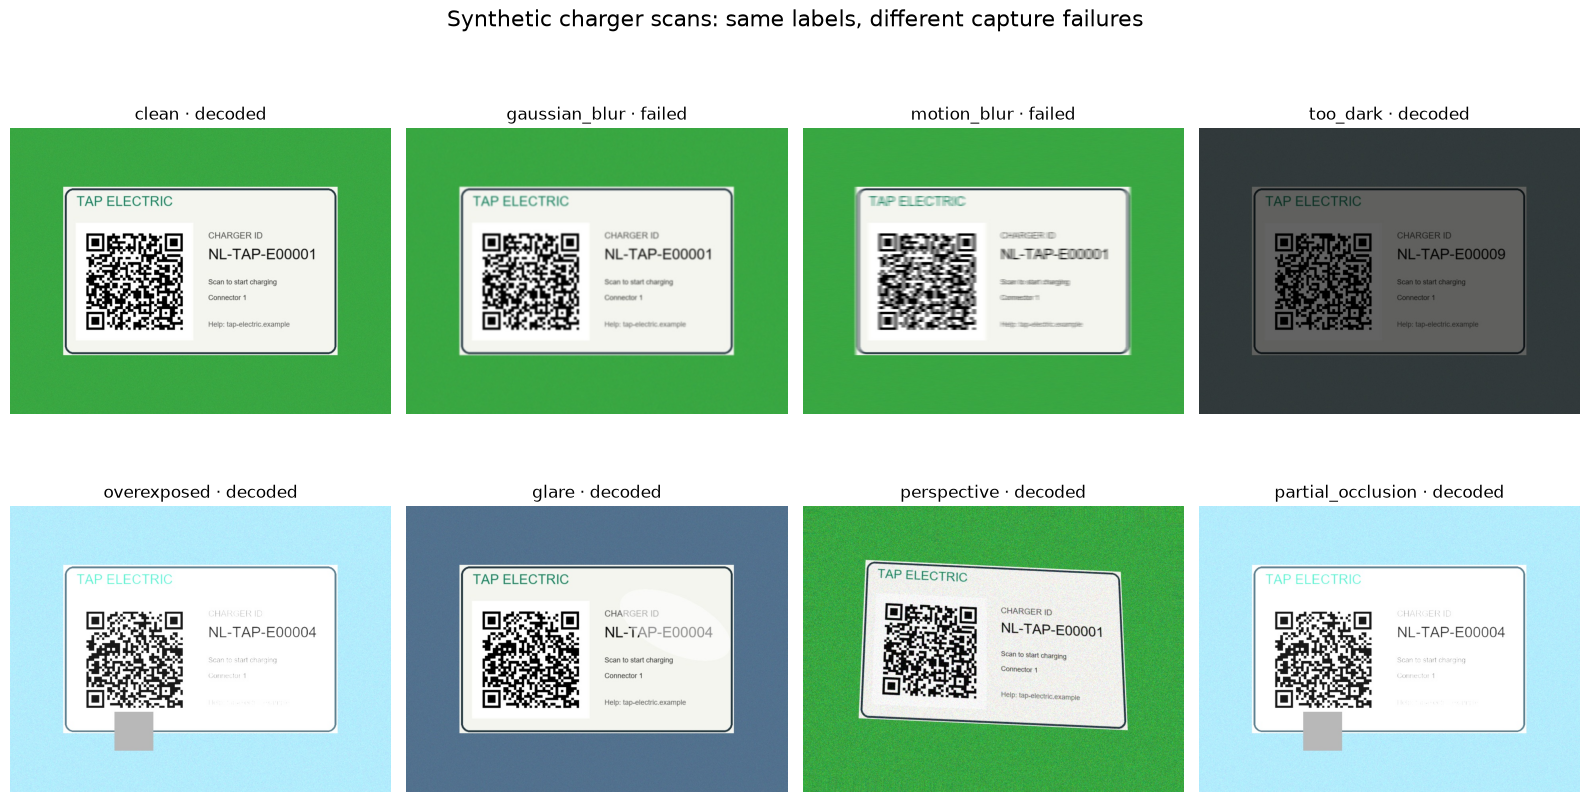

In [3]:
expanded = samples.explode('degradations')
wanted = [
    'clean',
    'gaussian_blur',
    'motion_blur',
    'too_dark',
    'overexposed',
    'glare',
    'perspective',
    'partial_occlusion',
]
chosen = []
for degradation in wanted:
    matches = expanded[expanded['degradations'] == degradation]
    if not matches.empty:
        chosen.append(matches.iloc[0])

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
for axis, row in zip(axes.flat, chosen, strict=False):
    axis.imshow(Image.open(OUTPUT_DIR / row['image_path']))
    state = 'decoded' if row['native_qr_success'] else 'failed'
    axis.set_title(f"{row['degradations']} · {state}")
    axis.axis('off')
for axis in axes.flat[len(chosen):]:
    axis.axis('off')
fig.suptitle('Synthetic charger scans: same labels, different capture failures', fontsize=16)
plt.tight_layout()

## 3. Degradation coverage and baseline QR recovery

A useful generated dataset must contain both successful and failed QR decodes. If every synthetic image remains readable, it does not represent the problem we are trying to solve.

,examples,recovery
degradations,,
motion_blur,6,0.0%
partial_occlusion,4,50.0%
gaussian_blur,6,66.7%
jpeg_compression,5,80.0%
glare,5,100.0%
faded,4,100.0%
noise,3,100.0%
clean,15,100.0%
overexposed,8,100.0%


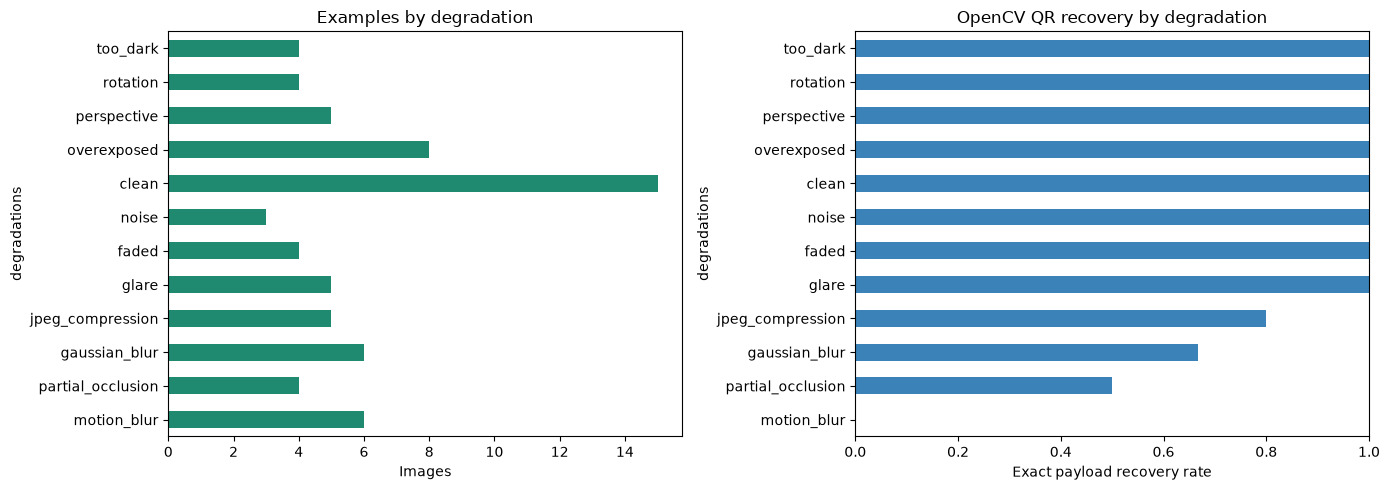

In [4]:
degradation_report = (
    expanded.groupby('degradations')
    .agg(examples=('example_id', 'count'), recovery=('native_qr_success', 'mean'))
    .sort_values('recovery')
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
degradation_report['examples'].plot.barh(
    ax=axes[0], color='#1f8a70', title='Examples by degradation'
)
degradation_report['recovery'].plot.barh(
    ax=axes[1], color='#3b82b8', title='OpenCV QR recovery by degradation'
)
axes[0].set_xlabel('Images')
axes[1].set_xlabel('Exact payload recovery rate')
axes[1].set_xlim(0, 1)
plt.tight_layout()
degradation_report.style.format({'recovery': '{:.1%}'})

## 4. Quality signals explain decoder failures

Blur uses variance of the Laplacian; brightness is mean grayscale intensity. These are operational signals used by the service to choose preprocessing, not labels supplied to TrOCR.

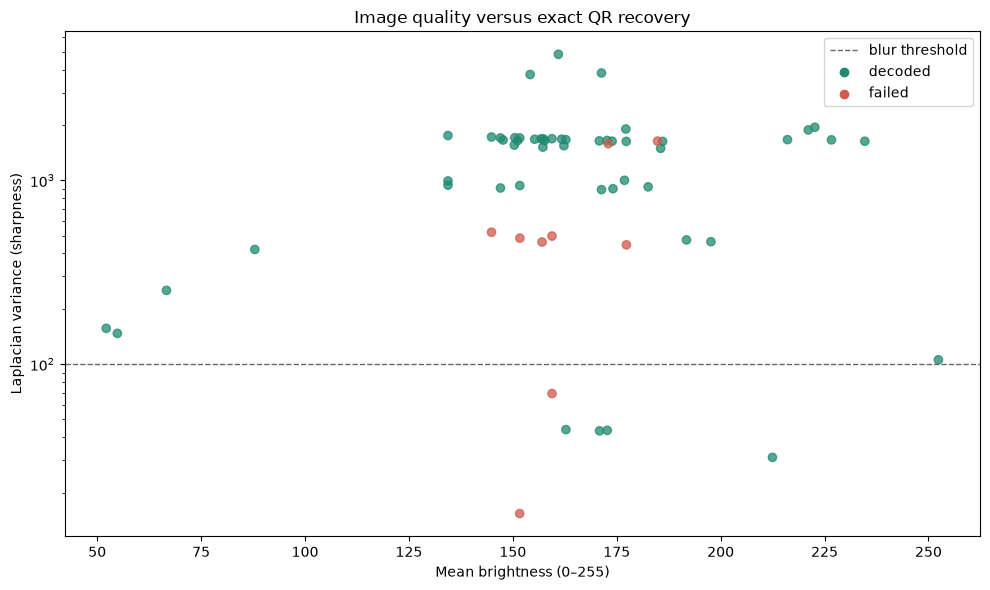

In [5]:
colors = samples['native_qr_success'].map({True: '#1f8a70', False: '#d05a4e'})
fig, axis = plt.subplots(figsize=(10, 6))
axis.scatter(samples['brightness_score'], samples['blur_score'], c=colors, alpha=0.75)
axis.axhline(100, color='#666666', linestyle='--', linewidth=1, label='blur threshold')
axis.set_xlabel('Mean brightness (0–255)')
axis.set_ylabel('Laplacian variance (sharpness)')
axis.set_yscale('log')
axis.set_title('Image quality versus exact QR recovery')
axis.scatter([], [], c='#1f8a70', label='decoded')
axis.scatter([], [], c='#d05a4e', label='failed')
axis.legend()
plt.tight_layout()

## 5. Prove that the split has no sticker leakage

In [6]:
splits_per_sticker = samples.groupby('sticker_id')['split'].nunique()
assert splits_per_sticker.max() == 1
assert samples.groupby('image_sha256')['split'].nunique().max() == 1
print(
    f"Leakage check passed: all {len(splits_per_sticker)} stickers and "
    "duplicate hashes stay in one split."
)

Leakage check passed: all 15 stickers and duplicate hashes stay in one split.


## 6. Where the hybrid data comes from

| Layer | Purpose | Source and policy |
|---|---|---|
| Synthetic stickers | Exact printed-ID labels for TrOCR; controlled failure coverage | Generated by this repository; safe to version by seed |
| Damaged QR pairs | Restoration and decoder benchmarking | [Kaggle: Damaged QR and Barcode Data](https://www.kaggle.com/datasets/tmuallim/damaged-qr-and-barcode-data), CC BY 4.0 |
| Unreadable QR benchmark | Scanned and simulated failure cases | [Figshare: QR Code Dataset V2](https://figshare.com/articles/dataset/QR_Code_Dataset_V2/28424213), CC BY 4.0 |
| Physical captures | Reality check for camera, glare, surface and device shift | Print synthetic stickers; hold photos out from training |
| Confirmed Tap scans | Final domain adaptation and production validation | Collected through the API with retention and access controls |

Third-party files are not committed automatically. Their provenance and licence must be recorded, and labels remain pending review unless the manifest explicitly marks them verified.

## 7. Import and train

Generate the larger dataset and import its exact labels:

```powershell
python -m scripts.generate_synthetic_dataset --chargers 500 --variants-per-charger 10 --seed 42
python -m scripts.import_dataset --manifest data/synthetic/manifest.json
```

Validate the data pipeline without downloading TrOCR:

```http
POST /api/v1/training/run
{"dry_run": true, "epochs": 3}
```

For real fine-tuning, install the `ml` extra, use a GPU, and submit `dry_run=false`. The saved checkpoint is evaluated through the complete QR → OCR → GPS resolver before the model registry can promote it.

## Interview takeaway

The synthetic dataset proves pipeline mechanics and gives TrOCR exact printed-ID supervision. Public degraded QR data expands restoration benchmarks. Physical captures expose the synthetic-to-real gap. Confirmed Tap scans are required before making any production accuracy claim.